# Module 2: Train and Evaluate a Keras-Based Classifier

This notebook completes the required tasks for Keras model training and validation.
It walks through the image dataset, builds a CNN, adds a checkpoint, and plots the training loss.

In [1]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

dataset_path = './images_dataSAT'
if not os.path.exists(dataset_path):
    alt_path = os.path.join('.', 'AI Capstone DL Projects', 'CNN Model Development', 'images_dataSAT')
    if os.path.exists(alt_path):
        dataset_path = alt_path

print('Dataset path:', dataset_path)
print('Exists:', os.path.exists(dataset_path))

c:\Users\Furqan Khan\AppData\Local\miniconda3\envs\agent_env2\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Dataset path: .\AI Capstone DL Projects\CNN Model Development\images_dataSAT
Exists: True


## Task 1: Recursively walk through the dataset and collect image file names

This uses `os.walk` to collect all image files in the dataset directory.

In [2]:
fnames = []
for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif', '.tif', '.tiff')):
            fnames.append(os.path.join(root, file))

print('Number of image files found:', len(fnames))
print('First 5 files:')
for path in fnames[:5]:
    print(path)

Number of image files found: 6000
First 5 files:
.\AI Capstone DL Projects\CNN Model Development\images_dataSAT\class_0_non_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg
.\AI Capstone DL Projects\CNN Model Development\images_dataSAT\class_0_non_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg
.\AI Capstone DL Projects\CNN Model Development\images_dataSAT\class_0_non_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg
.\AI Capstone DL Projects\CNN Model Development\images_dataSAT\class_0_non_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg
.\AI Capstone DL Projects\CNN Model Development\images_dataSAT\class_0_non_agri\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6248.jpg


## Task 2: Create the validation generator from the dataset path

Using Keras `ImageDataGenerator`, we create a validation generator with rescaling.

In [3]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    subset='training',
    seed=42
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    seed=42
)

print('Training class indices:', train_generator.class_indices)
print('Validation class indices:', validation_generator.class_indices)

Found 4800 images belonging to 2 classes.
Found 1200 images belonging to 2 classes.
Training class indices: {'class_0_non_agri': 0, 'class_1_agri': 1}
Validation class indices: {'class_0_non_agri': 0, 'class_1_agri': 1}


## Task 3: Count the total number of layers in the CNN model

The model below has four Conv2D layers and five Dense layers in total.

In [4]:
test_model = tf.keras.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

total_layers = len(test_model.layers)
print('Total number of layers:', total_layers)
test_model.summary()

Total number of layers: 14


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 415,425 (1.58 MB)

 Trainable params: 415,425 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Compile the CNN model

The model is compiled with the Adam optimizer and binary cross-entropy loss.

In [5]:
test_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('Model compiled successfully')

Model compiled successfully


## Task 5: Create the checkpoint callback for best accuracy

This callback saves the best model based on validation accuracy.

In [6]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

print(checkpoint)

## Task 6: Plot training and validation loss

We train the model for a short run and then plot the loss history.

150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 977ms/step - accuracy: 0.7810 - loss: 0.3875
Epoch 1: val_accuracy improved from None to 0.95000, saving model to best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.9027 - loss: 0.2109 - val_accuracy: 0.9500 - val_loss: 0.1103


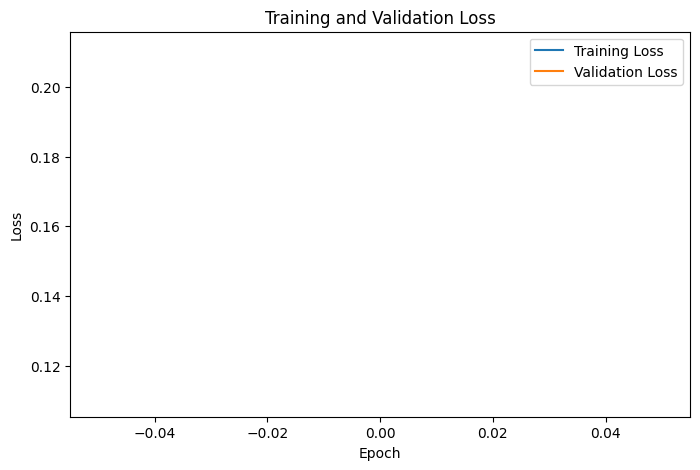

In [7]:
history = test_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=1,
    callbacks=[checkpoint]
)

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()